In [1]:
import pandas  as pd
import numpy as np

In [26]:
df = pd.read_csv("powerplant_data.csv")

In [27]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT -> Temperature
# V -> vaccum
# AP -> Pressure
# RH -> humidity
# PE -> Produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [9]:
y_train

5487    442.75
3522    432.52
6916    428.80
7544    426.07
7600    436.58
         ...  
5734    436.44
5191    441.20
5390    464.26
860     440.45
7270    484.44
Name: PE, Length: 7654, dtype: float64

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [11]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype= torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype= torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1, 1)

In [12]:
from torch.utils.data import TensorDataset, DataLoader

# convert dataset into a format acceptable by ANN
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [13]:
# Loads dataset into Neuron by batches 
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Deep Learning

In [14]:
# Define the model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6), #in_features, out_features
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6, 6), #in_features, out_features
            nn.ReLU(),

            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
            return self.model(x)

In [15]:
import torch.optim as optim

model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [18]:
epochs = 100
train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(epochs):

    # ------------------ Training ------------------
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        outputs = model(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # ---------------- Validation ------------------
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for xb, yb in test_loader:

            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Train Loss: {epoch_train_loss:.4f}, "
        f"Validation Loss: {epoch_val_loss:.4f}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

Epoch 1/100, Train Loss: 20.9497, Validation Loss: 19.2782
Epoch 2/100, Train Loss: 20.8961, Validation Loss: 18.8646
Epoch 3/100, Train Loss: 20.9419, Validation Loss: 18.8736
Epoch 4/100, Train Loss: 20.8299, Validation Loss: 18.9211
Epoch 5/100, Train Loss: 20.9305, Validation Loss: 19.0425
Epoch 6/100, Train Loss: 20.8303, Validation Loss: 18.8887
Epoch 7/100, Train Loss: 20.8323, Validation Loss: 18.9078
Epoch 8/100, Train Loss: 20.7365, Validation Loss: 18.7367
Epoch 9/100, Train Loss: 20.6646, Validation Loss: 19.3029
Epoch 10/100, Train Loss: 20.8283, Validation Loss: 19.2026
Epoch 11/100, Train Loss: 20.7844, Validation Loss: 19.2508
Epoch 12/100, Train Loss: 20.6379, Validation Loss: 18.6991
Epoch 13/100, Train Loss: 20.6547, Validation Loss: 19.0587
Epoch 14/100, Train Loss: 20.6070, Validation Loss: 18.8101
Epoch 15/100, Train Loss: 20.8139, Validation Loss: 18.9676
Epoch 16/100, Train Loss: 20.7540, Validation Loss: 19.6892
Epoch 17/100, Train Loss: 20.6841, Validation Los

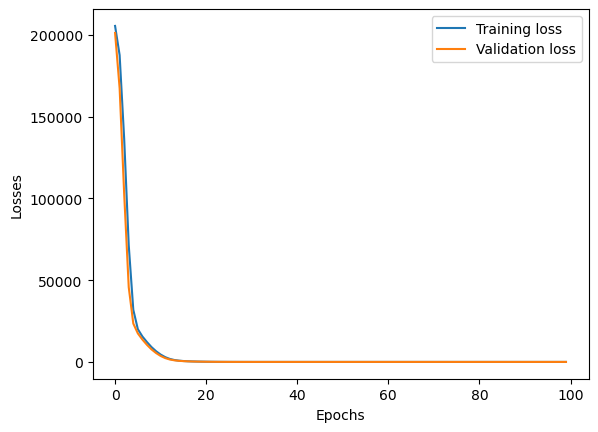

In [17]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training_loss" : train_losses,
    "Validation_loss" : val_losses
})

plt.plot(loss_df["Training_loss"], label="Training loss")
plt.plot(loss_df["Validation_loss"], label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [19]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [22]:
# Evaluation
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE = ", train_mse_loss.item())    
print("Testing MSE = ", test_mse_loss.item())      

Training MSE =  20.224576950073242
Testing MSE =  18.534303665161133


In [23]:
from sklearn.metrics import r2_score

print("r^2 score = ", r2_score(y_test, test_preds))

r^2 score =  0.9352273934297848


In [24]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,434.873749,433.27
1,436.515717,438.16
2,461.457855,458.42
3,476.594696,480.82
4,435.092346,441.41
...,...,...
1909,451.137787,456.70
1910,431.169006,438.04
1911,467.681732,467.80
1912,430.601501,437.14
